In [15]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from langchain_core.messages import convert_to_messages
from IPython.display import Image, display
from dotenv import load_dotenv

load_dotenv()

True

In [26]:
llm = ChatGroq(model="llama3-8b-8192", temperature=0.4)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002373481FC50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023734851E50>, model_name='llama3-8b-8192', temperature=0.4, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [27]:
@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help."""
    # This tool is not returning anything: we're just using it
    # as a way for LLM to signal that it needs to hand off to another agent
    return


@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help."""
    return

In [28]:
def travel_advisor(
    state: MessagesState,
) -> Command[Literal["hotel_advisor", "__end__"]]:
    system_prompt = (
        "You are a general travel expert that can recommend travel destinations (e.g. countries, cities, etc). "
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    # If there are tool calls, the LLM needs to hand off to another agent
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        # NOTE: it's important to insert a tool message here because LLM providers are expecting
        # all AI messages to be followed by a corresponding tool result message
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="hotel_advisor", update={"messages": [ai_msg, tool_msg]})

    # If the expert has an answer, return it directly to the user
    return {"messages": [ai_msg]}

In [29]:
def hotel_advisor(
    state: MessagesState,
) -> Command[Literal["travel_advisor", "__end__"]]:
    system_prompt = (
        "You are a hotel expert that can provide hotel recommendations for a given destination. "
        "If you need help picking travel destinations, ask 'travel_advisor' for help."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([transfer_to_travel_advisor]).invoke(messages)
    # If there are tool calls, the LLM needs to hand off to another agent
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        # NOTE: it's important to insert a tool message here because LLM providers are expecting
        # all AI messages to be followed by a corresponding tool result message
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="travel_advisor", update={"messages": [ai_msg, tool_msg]})

    # If the expert has an answer, return it directly to the user
    return {"messages": [ai_msg]}

In [30]:
builder = StateGraph(MessagesState)
builder.add_node("travel_advisor", travel_advisor)
builder.add_node("hotel_advisor", hotel_advisor)
# we'll always start with a general travel advisor
builder.add_edge(START, "travel_advisor")

graph = builder.compile()

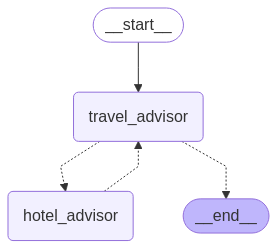

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [38]:
for chunk in graph.stream(
    {"messages": [("user", "i want a detailed itineary for travelling in Manhattan. Also give me cheap hotel recommendations")]}
):
    pretty_print_messages(chunk)

Update from node travel_advisor:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_hotel_advisor (call_n1mh)
 Call ID: call_n1mh
  Args:
    some_argument: need_hotel_recommendations
================================= Tool Message =================================

Successfully transferred


Update from node hotel_advisor:


================================== Ai Message ==================================

Here's a detailed itinerary for traveling in Manhattan:

**Day 1:**

* Morning: Start your day with a hearty breakfast at a classic New York diner, such as Sarabeth's or Russ & Daughters Cafe.
* 9:00 AM: Visit the iconic Empire State Building for panoramic views of the city.
* 11:00 AM: Take a stroll through Central Park, exploring the scenic paths, lakes, and landmarks like the Loeb Boathouse and the Alice in Wonderland statue.
* 1:00 PM: Grab lunch at a classic New York pizzeria, such as Lombardi's or Joe's Pizza.
* 2:30 PM: 